# Point Clouds with Ripser

This notebook begins the **Ripser** section of the Topological Data Analysis repository.

We have developed the mathematical foundations

$$
\text{metric spaces}
\longrightarrow
\text{simplicial complexes}
\longrightarrow
\text{homology}
\longrightarrow
\text{filtrations}
\longrightarrow
\text{persistent homology}.
$$

We now begin using a computational TDA library. The goal is not simply to call `ripser()` as a black box, but to understand what kind of geometric data it receives.

### Learning goals

By the end of this notebook you should be able to:

- define and represent a finite point cloud;
- distinguish a point cloud from a simplicial complex;
- compute pairwise distances;
- visualize point clouds in two and three dimensions;
- generate synthetic and noisy point clouds;
- pass a point cloud to Ripser;
- understand the basic roles of `maxdim` and `thresh`.

## 1. What is a point cloud?

A **point cloud** is a finite collection of points sampled from some ambient space.

For a Euclidean point cloud,

$$
X=\{x_1,\ldots,x_n\},
\qquad x_i\in\mathbb{R}^d.
$$

Computationally, we usually store it as an $n\times d$ array. Each row is one point.

A point cloud contains **points**, not edges, triangles, or higher-dimensional simplices. Those additional objects will be constructed from the metric information.

### Example

Consider

$$
X=\{(0,0),(1,0),(1,1),(0,1)\}.
$$

These four points form the vertices of a square. But the point cloud itself does not yet contain the four edges or the filled square.

### Non-example

A collection such as

$$
K=\{\{1\},\{2\},\{1,2\}\}
$$

is naturally interpreted as a simplicial complex, not as a point cloud.

This distinction will be important when Ripser constructs a filtration from metric data.

## 2. Representing a point cloud

### Pseudocode

```text
Create an n × d array.
Each row represents one sampled point.
Store the array as the point cloud.
Inspect its number of points and ambient dimension.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define four points in the plane.
points = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])

# The number of rows is the number of sampled points.
num_points = points.shape[0]

# The number of columns is the ambient dimension.
ambient_dimension = points.shape[1]

print("Number of points:", num_points)
print("Ambient dimension:", ambient_dimension)
print("Point cloud:\n", points)

Number of points: 4
Ambient dimension: 2
Point cloud:
 [[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]]


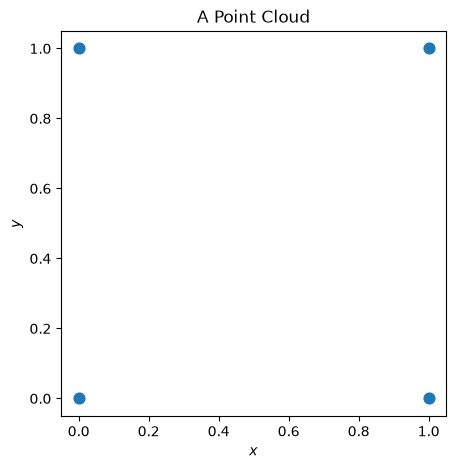

In [2]:
# Plot the sampled points without adding any edges or faces.
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(points[:, 0], points[:, 1], s=60)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")
ax.set_title("A Point Cloud")

plt.show()

Notice what is **not** drawn. We see four points, but no edges and no filled square.

This is deliberate: the point cloud contains only the sampled points. Later, a construction such as the Vietoris–Rips filtration will use distances between these points to create simplices.

## 3. A lightweight `PointCloud` object

A point cloud is a mathematical object with associated data and operations, so a small Python class is natural.

The purpose here is **not** to teach object-oriented programming. The class simply makes the mathematical structure explicit.

### Pseudocode

```text
Define a PointCloud class.

Store the points.

Provide:
    number of points
    ambient dimension
    pairwise distance matrix
    basic visualization
```

In [3]:
from scipy.spatial.distance import cdist


class PointCloud:
    '''A finite point cloud in a Euclidean space.'''

    def __init__(self, points):
        # Store the coordinates as a NumPy array.
        self.points = np.asarray(points, dtype=float)

        # Require one row per point and one column per coordinate.
        if self.points.ndim != 2:
            raise ValueError("A point cloud must be a two-dimensional array.")

    @property
    def num_points(self):
        # The number of rows is the number of sampled points.
        return self.points.shape[0]

    @property
    def ambient_dimension(self):
        # The number of columns is the ambient dimension.
        return self.points.shape[1]

    def distance_matrix(self):
        # Compute all pairwise Euclidean distances.
        return cdist(self.points, self.points)

    def plot(self, ax=None, **kwargs):
        # Create an axis when one is not supplied.
        if ax is None:
            _, ax = plt.subplots()

        # This basic plotting method is intended for 2D point clouds.
        if self.ambient_dimension != 2:
            raise ValueError("The basic plot method is for 2D point clouds.")

        # Plot the sampled points.
        ax.scatter(self.points[:, 0], self.points[:, 1], **kwargs)

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        ax.set_aspect("equal")

        return ax

In [4]:
# Create a PointCloud object from the square example.
square = PointCloud(points)

print("Number of points:", square.num_points)
print("Ambient dimension:", square.ambient_dimension)

Number of points: 4
Ambient dimension: 2


In [5]:
# Compute and display the pairwise distance matrix.
distance_matrix = square.distance_matrix()

print(np.round(distance_matrix, 3))

[[0.    1.    1.414 1.   ]
 [1.    0.    1.    1.414]
 [1.414 1.    0.    1.   ]
 [1.    1.414 1.    0.   ]]


For a point cloud

$$
X=\{x_1,\ldots,x_n\},
$$

the distance matrix is

$$
D_{ij}=d(x_i,x_j)=\|x_i-x_j\|.
$$

It satisfies

$$
D_{ii}=0,
\qquad
D_{ij}=D_{ji}.
$$

Many TDA constructions depend on this metric information rather than on the particular coordinates used to represent the points.

## 4. Point clouds in three dimensions

A point cloud may live in any dimension:

$$
X\subseteq\mathbb{R}^d.
$$

For example, let us sample points from the unit sphere

$$
S^2=\{(x,y,z)\in\mathbb{R}^3:x^2+y^2+z^2=1\}.
$$

The point cloud contains only sampled points; it does not contain a triangulated surface.

### Pseudocode

```text
Generate random vectors in R^3.
Normalize each vector to length 1.
Store the normalized vectors as the point cloud.
Plot the sample.
```

In [6]:
# Use a fixed seed so that the example is reproducible.
rng = np.random.default_rng(7)

# Generate random vectors in three dimensions.
sphere_points = rng.normal(size=(300, 3))

# Normalize each vector so that it lies on the unit sphere.
sphere_points /= np.linalg.norm(sphere_points, axis=1, keepdims=True)

# Store the sample as a PointCloud object.
sphere = PointCloud(sphere_points)

print("Number of points:", sphere.num_points)
print("Ambient dimension:", sphere.ambient_dimension)

Number of points: 300
Ambient dimension: 3


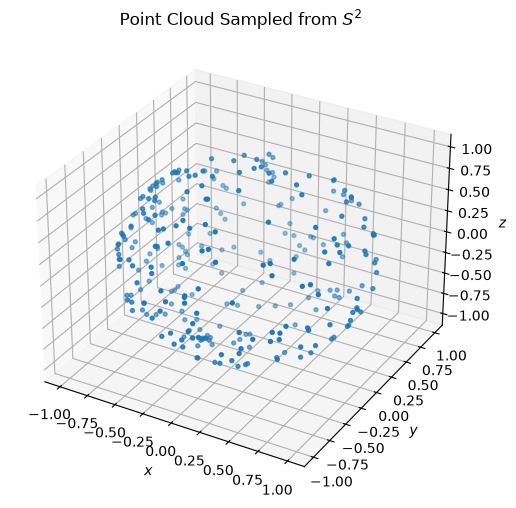

In [7]:
# Visualize the three-dimensional point cloud.
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    sphere.points[:, 0],
    sphere.points[:, 1],
    sphere.points[:, 2],
    s=8,
)

ax.set_title("Point Cloud Sampled from $S^2$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")

plt.show()

## 5. Noisy point clouds

Real data are rarely exact samples of an ideal mathematical object.

For a circle,

$$
S^1=\{(x,y)\in\mathbb{R}^2:x^2+y^2=1\},
$$

we may observe

$$
x_i=\bar{x}_i+\varepsilon_i,
$$

where $\bar{x}_i$ lies on the circle and $\varepsilon_i$ represents noise.

Recovering robust topological information from such imperfect observations is one of the central motivations for TDA.

### Pseudocode

```text
Choose points around a circle.
Add small random perturbations.
Store the resulting points.
Visualize the noisy point cloud.
```

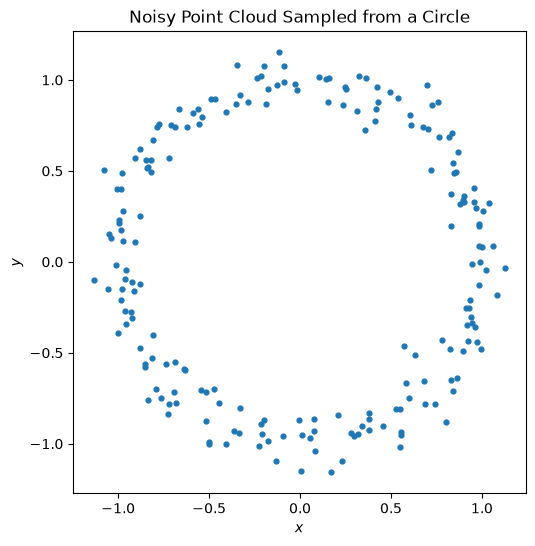

In [8]:
# Generate evenly spaced points on the unit circle.
rng = np.random.default_rng(12)
angles = np.linspace(0, 2 * np.pi, 200, endpoint=False)

circle_points = np.column_stack([
    np.cos(angles),
    np.sin(angles),
])

# Add Gaussian noise to simulate imperfect observations.
noise = 0.08 * rng.normal(size=circle_points.shape)
noisy_circle_points = circle_points + noise

# Store the noisy observations as a point cloud.
noisy_circle = PointCloud(noisy_circle_points)

# Visualize the noisy sample.
fig, ax = plt.subplots(figsize=(6, 6))
noisy_circle.plot(ax=ax, s=12)

ax.set_title("Noisy Point Cloud Sampled from a Circle")
plt.show()

The underlying circle has one prominent one-dimensional hole, but the data contain only finitely many noisy observations.

The central TDA question is therefore:

> **Can we recover the topology of an underlying geometric object from a finite point cloud?**

Persistent homology approaches this by constructing a family of simplicial complexes at different distance scales.

## 6. Introducing Ripser

[`ripser`](https://ripser.scikit-tda.org/) is a Python implementation for computing persistent homology efficiently.

At its simplest, Ripser accepts a point cloud:

```python
result = ripser(points)
```

where `points` is typically an $n\times d$ NumPy array.

Conceptually,

$$
X=\{x_1,\ldots,x_n\}\subseteq\mathbb{R}^d.
$$

Ripser uses the metric information in $X$ to construct a Vietoris–Rips filtration and compute persistent homology.

We will study the Vietoris–Rips construction in detail in the next notebook. Here we focus on the point-cloud interface.

### Pseudocode

```text
Create a point cloud X.
Pass X to ripser.
Choose the maximum homology dimension.
Store the returned result.
Inspect the persistence diagrams.
```

In [9]:
from ripser import ripser

# Pass the noisy circle point cloud to Ripser.
result = ripser(
    noisy_circle.points,
    maxdim=1,
)

# Display the names of the main returned quantities.
print(result.keys())

dict_keys(['dgms', 'cocycles', 'num_edges', 'dperm2all', 'idx_perm', 'r_cover'])


In [10]:
# Extract the persistence diagrams from the Ripser result.
diagrams = result["dgms"]

# Ripser returns one persistence diagram for each requested homology dimension.
for dimension, diagram in enumerate(diagrams):
    print(f"H_{dimension}: shape = {diagram.shape}")

H_0: shape = (200, 2)
H_1: shape = (18, 2)


The key output for us is `dgms`, the collection of persistence diagrams.

At this point we will not study their detailed interpretation. That will be the subject of the following notebooks.

The important data flow is

$$
\boxed{
\text{point cloud}
\longrightarrow
\text{metric information}
\longrightarrow
\text{Vietoris--Rips filtration}
\longrightarrow
\text{persistent homology}
}.
$$

## 7. The `maxdim` parameter

The parameter `maxdim` controls the highest homology dimension computed.

For example,

```python
ripser(points, maxdim=0)
```

computes $H_0$, while

```python
ripser(points, maxdim=1)
```

computes $H_0$ and $H_1$.

Similarly, `maxdim=2` includes $H_2$.

The choice should reflect the topology you want to investigate and the computational resources available.

In [11]:
# Compute only zero-dimensional persistent homology.
h0_result = ripser(
    noisy_circle.points,
    maxdim=0,
)

print("Number of returned diagrams:", len(h0_result["dgms"]))

# Compute zero- and one-dimensional persistent homology.
h01_result = ripser(
    noisy_circle.points,
    maxdim=1,
)

print("Number of returned diagrams:", len(h01_result["dgms"]))

Number of returned diagrams: 1
Number of returned diagrams: 2


## 8. The `thresh` parameter

Ripser also accepts a maximum filtration scale through `thresh`.

Conceptually, this restricts the computation to scales

$$
\varepsilon\leq\text{thresh}.
$$

This can be useful for large point clouds or when only a particular range of scales is relevant.

In [12]:
# Restrict the computation to a finite range of filtration scales.
threshold_result = ripser(
    noisy_circle.points,
    maxdim=1,
    thresh=1.5,
)

print("Computed homology dimensions:", len(threshold_result["dgms"]))

Computed homology dimensions: 2


## 9. Another example: a figure-eight

Different point clouds can encode different topology.

A figure-eight consists of two loops joined together. We can sample points from the two loops and then add noise.

### Pseudocode

```text
Sample points from the first loop.
Sample points from the second loop.
Combine the two samples.
Add small noise.
Visualize the resulting point cloud.
```

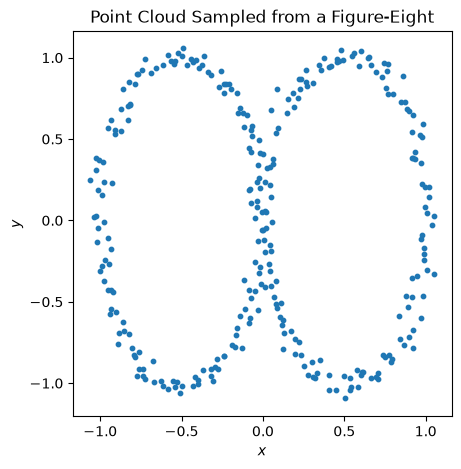

In [13]:
# Sample two circular loops.
rng = np.random.default_rng(21)
angles = np.linspace(0, 2 * np.pi, 150, endpoint=False)

left_loop = np.column_stack([
    -0.5 + 0.5 * np.cos(angles),
    np.sin(angles),
])

right_loop = np.column_stack([
    0.5 + 0.5 * np.cos(angles),
    np.sin(angles),
])

# Combine the two loops and add a small amount of noise.
figure_eight_points = np.vstack([left_loop, right_loop])
figure_eight_points += 0.04 * rng.normal(size=figure_eight_points.shape)

# Store the data as a point cloud.
figure_eight = PointCloud(figure_eight_points)

# Visualize the sampled figure-eight.
fig, ax = plt.subplots(figsize=(7, 5))
figure_eight.plot(ax=ax, s=10)

ax.set_title("Point Cloud Sampled from a Figure-Eight")
plt.show()

## 10. Geometry, metric, and topology

It is useful to keep three levels separate.

### Geometric data

$$
X=\{x_1,\ldots,x_n\}.
$$

### Metric information

$$
d(x_i,x_j).
$$

### Topological information

The homology of spaces or filtrations constructed from the metric data.

Thus the TDA pipeline begins with

$$
\boxed{
\text{geometry}
\longrightarrow
\text{metric}
\longrightarrow
\text{topology}
}.
$$

Ripser automates much of the final computational step, but understanding the intermediate mathematical objects is essential.

## 11. Exercises

### Exercise 1 — Point-cloud representation

Create

$$
X=\{(0,0),(2,0),(2,2),(0,2)\}.
$$

Store it as a NumPy array and verify its shape.

### Exercise 2 — Distance matrix

Compute its Euclidean distance matrix. Verify

$$
D_{ij}=D_{ji},
\qquad
D_{ii}=0.
$$

### Exercise 3 — Sampling density

Generate noisy circles with 50, 100, and 500 points. Compare the samples visually.

### Exercise 4 — Noise

Repeat the circle experiment with noise levels

$$
\sigma=0,\;0.02,\;0.1,\;0.25.
$$

What changes visually?

### Exercise 5 — Sphere

Generate a point cloud with 1000 points on $S^2$ and visualize it.

### Exercise 6 — Ripser

Run Ripser on the noisy circle with `maxdim=0` and then with `maxdim=1`. How does the returned structure change?

### Exercise 7 — Threshold

Run Ripser with several values of `thresh` and record how the output changes.

### Exercise 8 — Your own point cloud

Choose a geometric object, sample a point cloud from it, visualize it, and compute its pairwise distance matrix.

## Summary

A point cloud is a finite sample

$$
X=\{x_1,\ldots,x_n\}
$$

from a metric or geometric space.

Its geometry is encoded by distances between points. Ripser uses this metric information to construct a Vietoris–Rips filtration and compute persistent homology.

The basic computational pipeline is

$$
\boxed{
\text{sample data}
\rightarrow
\text{point cloud}
\rightarrow
\text{pairwise distances}
\rightarrow
\text{Ripser}
}.
$$

The next notebook will make the Vietoris–Rips construction explicit and show how the filtration scale is related to the distances in the point cloud.

## References

1. Ulrich Bauer, **Ripser: efficient computation of Vietoris–Rips persistence barcodes**, *Journal of Applied and Computational Topology* 5 (2021), 391–423.

2. Frederick Chazal and Bertrand Michel, **An Introduction to Topological Data Analysis: Fundamental and Practical Aspects for Data Scientists**, *Frontiers in Artificial Intelligence* 4 (2021), 667963.

3. Herbert Edelsbrunner and John Harer, **Computational Topology: An Introduction**, American Mathematical Society, 2010.

4. Gunnar Carlsson, **Topology and Data**, *Bulletin of the American Mathematical Society* 46 (2009), 255–308.